In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install -q dagshub mlflow

import dagshub
import mlflow
from kaggle_secrets import UserSecretsClient
import os

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow.sklearn
import dagshub

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE


user_secrets = UserSecretsClient()
DAGSHUB_TOKEN = user_secrets.get_secret("DAGSHUB_TOKEN")
DAGSHUB_USERNAME = user_secrets.get_secret("DAGSHUB_USERNAME")

repo_name = "ml_ass2"

mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{repo_name}.mlflow")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

# dagshub.init(repo_name=repo_name, repo_owner=DAGSHUB_USERNAME, mlflow=True)

print("Connected to DagsHub + MLflow successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 89.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 69.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
mlflow.set_experiment("DT_Training")

<Experiment: artifact_location='mlflow-artifacts:/aa4b289a19974d07bc8aab9d4bebb057', creation_time=1777970234813, experiment_id='5', last_update_time=1777970234813, lifecycle_stage='active', name='DT_Training', tags={}, trace_location=None, workspace='default'>

**data load and merge**

In [4]:
df_trans = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv")
df_id = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv")

df = df_trans.merge(df_id, on="TransactionID", how="left")

print(f"Transaction table : {df_trans.shape}")
print(f"Identity table    : {df_id.shape}")
print(f"Merged shape      : {df.shape}")

import gc
del df_trans, df_id
gc.collect()

Transaction table : (590540, 394)
Identity table    : (144233, 41)
Merged shape      : (590540, 434)


35

**eda**

**target distribution**

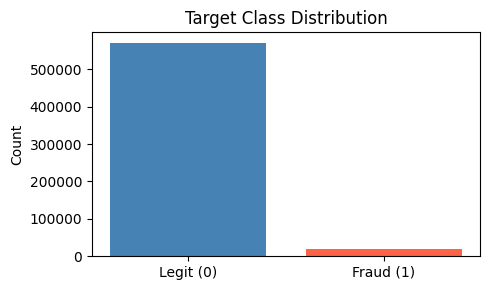

Legit : 569,877  (96.5%)
Fraud : 20,663  (3.5%)


In [5]:
counts = df['isFraud'].value_counts()

plt.figure(figsize=(5, 3))
plt.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Legit : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Fraud : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")

**transaction amount distribution**

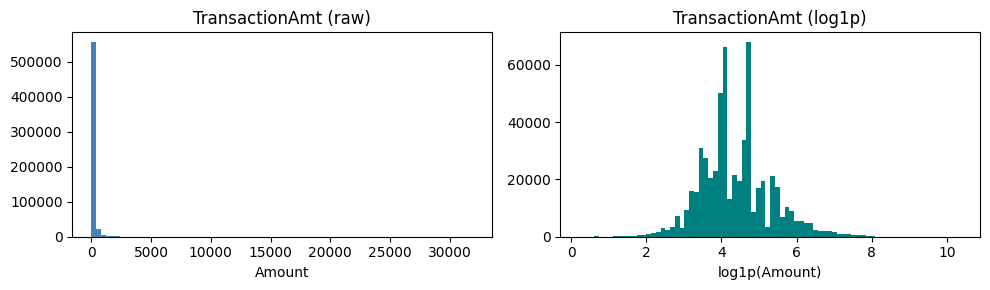

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(df['TransactionAmt'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('TransactionAmt (raw)')
axes[0].set_xlabel('Amount')

axes[1].hist(np.log1p(df['TransactionAmt']), bins=80, color='teal', edgecolor='none')
axes[1].set_title('TransactionAmt (log1p)')
axes[1].set_xlabel('log1p(Amount)')

plt.tight_layout()
plt.show()

**missing values**

  Threshold 60% → would DROP 208 columns  | KEEP 206 of 414 columns with NaN
  Threshold 90% → would DROP  12 columns  | KEEP 402 of 414 columns with NaN
  Threshold 95% → would DROP   9 columns  | KEEP 405 of 414 columns with NaN



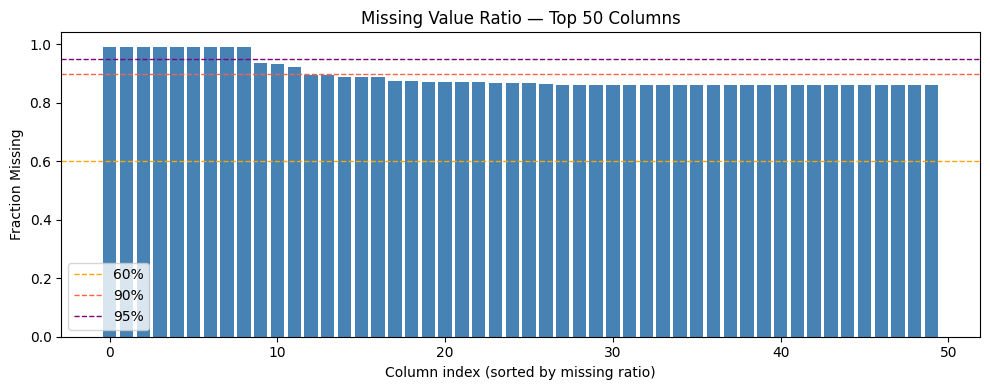

In [6]:
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]   # only show columns that have any missing

thresholds = [0.60, 0.90, 0.95]
for t in thresholds:
    n = (miss > t).sum()
    print(f"  Threshold {int(t*100)}% → would DROP {n:3d} columns  "
          f"| KEEP {len(miss) - n} of {len(miss)} columns with NaN")


print()


top_miss = miss.head(50) 

plt.figure(figsize=(10, 4))
plt.bar(range(len(top_miss)), top_miss.values, color='steelblue')
plt.axhline(0.60, color='orange', linestyle='--', linewidth=1, label='60%')
plt.axhline(0.90, color='tomato', linestyle='--', linewidth=1, label='90%')
plt.axhline(0.95, color='purple', linestyle='--', linewidth=1, label='95%')

plt.title('Missing Value Ratio — Top 50 Columns')
plt.ylabel('Fraction Missing')
plt.xlabel('Column index (sorted by missing ratio)')
plt.legend()
plt.tight_layout()
plt.show()

**categorical columns**

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {len(cat_cols)}\n")
for col in cat_cols:
    print(f"  {col:20s} | unique: {df[col].nunique():5d} | "
          f"missing: {df[col].isnull().mean():.2f} | "
          f"top: {df[col].value_counts().index[0]}")

Categorical columns: 31

  ProductCD            | unique:     5 | missing: 0.00 | top: W
  card4                | unique:     4 | missing: 0.00 | top: visa
  card6                | unique:     4 | missing: 0.00 | top: debit
  P_emaildomain        | unique:    59 | missing: 0.16 | top: gmail.com
  R_emaildomain        | unique:    60 | missing: 0.77 | top: gmail.com
  M1                   | unique:     2 | missing: 0.46 | top: T
  M2                   | unique:     2 | missing: 0.46 | top: T
  M3                   | unique:     2 | missing: 0.46 | top: T
  M4                   | unique:     3 | missing: 0.48 | top: M0
  M5                   | unique:     2 | missing: 0.59 | top: F
  M6                   | unique:     2 | missing: 0.29 | top: F
  M7                   | unique:     2 | missing: 0.59 | top: F
  M8                   | unique:     2 | missing: 0.59 | top: F
  M9                   | unique:     2 | missing: 0.59 | top: T
  id_12                | unique:     2 | missing: 0.76 

In [9]:
all_uniques = {col: df[col].nunique() for col in cat_cols}

for col, count in sorted(all_uniques.items(), key=lambda item: item[1], reverse=True):
    print(f"{col:20s} | Unique Values: {count}")

DeviceInfo           | Unique Values: 1786
id_33                | Unique Values: 260
id_31                | Unique Values: 130
id_30                | Unique Values: 75
R_emaildomain        | Unique Values: 60
P_emaildomain        | Unique Values: 59
ProductCD            | Unique Values: 5
card4                | Unique Values: 4
card6                | Unique Values: 4
id_34                | Unique Values: 4
M4                   | Unique Values: 3
id_15                | Unique Values: 3
id_23                | Unique Values: 3
M1                   | Unique Values: 2
M2                   | Unique Values: 2
M3                   | Unique Values: 2
M5                   | Unique Values: 2
M6                   | Unique Values: 2
M7                   | Unique Values: 2
M8                   | Unique Values: 2
M9                   | Unique Values: 2
id_12                | Unique Values: 2
id_16                | Unique Values: 2
id_27                | Unique Values: 2
id_28                | Unique 

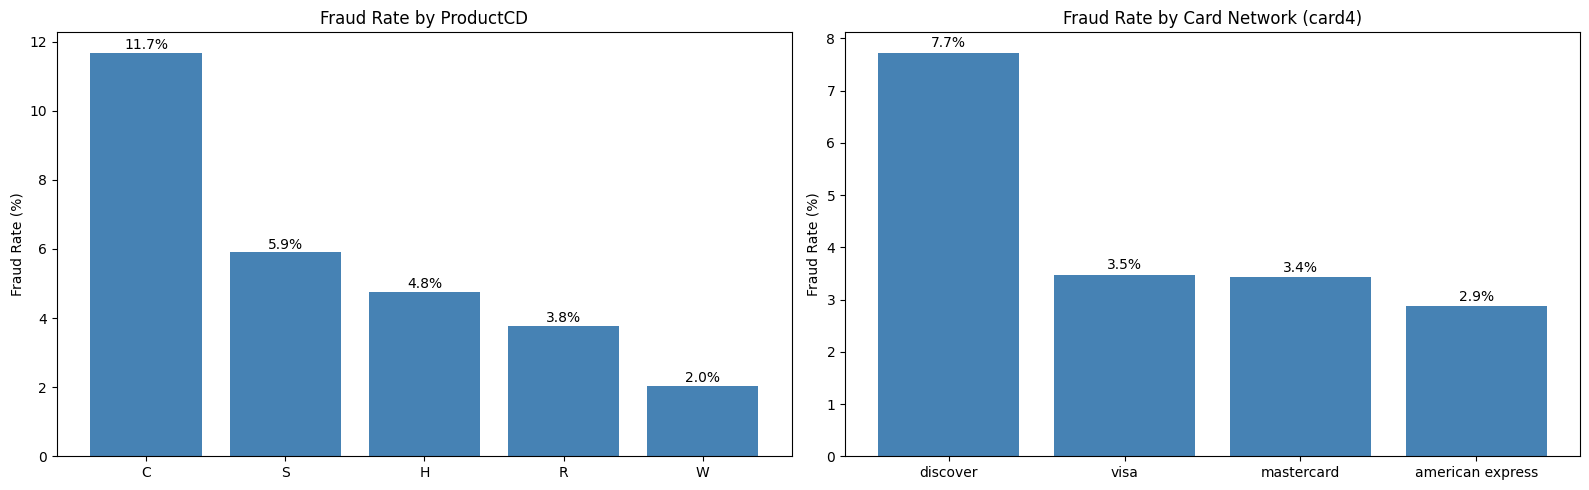

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ProductCD
prod_fraud = df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
axes[0].bar(prod_fraud.index, prod_fraud.values * 100, color='steelblue')
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(prod_fraud.values):
    axes[0].text(i, v * 100 + 0.1, f'{v*100:.1f}%', ha='center')

# Card
card_fraud = df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)
axes[1].bar(card_fraud.index, card_fraud.values * 100, color='steelblue')
axes[1].set_title('Fraud Rate by Card Network (card4)')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(card_fraud.values):
    axes[1].text(i, v * 100 + 0.1, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

**time-based analysis**

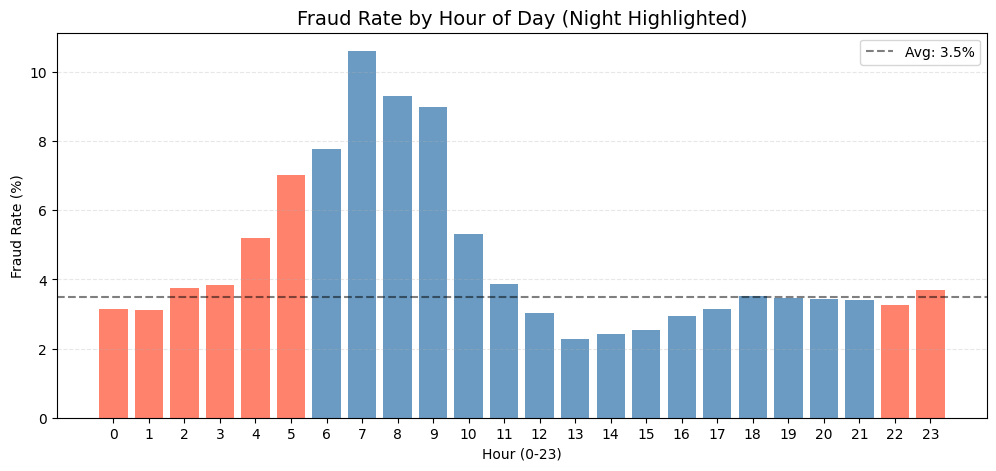

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

hourly_fraud = df['isFraud'].groupby((df['TransactionDT'] // 3600) % 24).mean()

plt.figure(figsize=(12, 5))

colors = ['tomato' if (x < 6 or x >= 22) else 'steelblue' for x in hourly_fraud.index]

plt.bar(hourly_fraud.index, hourly_fraud.values * 100, color=colors, alpha=0.8)

global_mean = df['isFraud'].mean() * 100
plt.axhline(global_mean, color='black', linestyle='--', alpha=0.5, label=f'Avg: {global_mean:.1f}%')

plt.title('Fraud Rate by Hour of Day (Night Highlighted)', fontsize=14)
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

**card-based analysis**

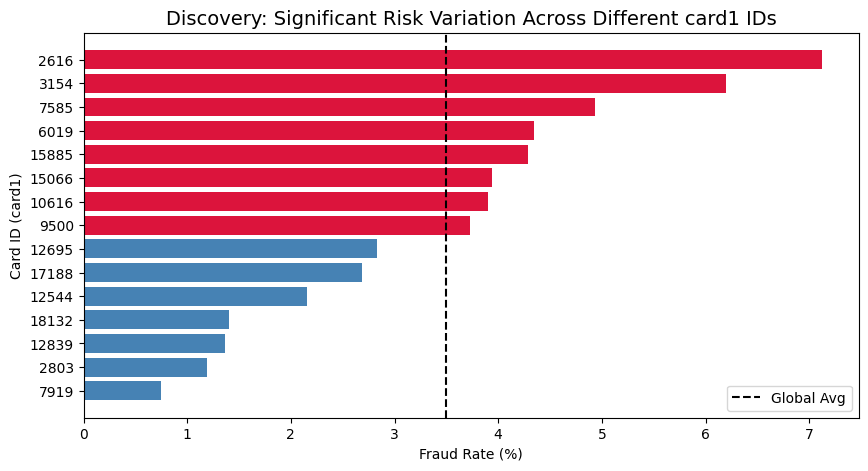

In [12]:
top_cards = df['card1'].value_counts().head(15).index
card_risk = df[df['card1'].isin(top_cards)].groupby('card1')['isFraud'].mean().sort_values()

plt.figure(figsize=(10, 5))
colors = ['steelblue' if x < card_risk.mean() else 'crimson' for x in card_risk.values]
plt.barh(card_risk.index.astype(str), card_risk.values * 100, color=colors)

plt.axvline(df['isFraud'].mean() * 100, color='black', linestyle='--', label='Global Avg')
plt.title('Discovery: Significant Risk Variation Across Different card1 IDs', fontsize=14)
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Card ID (card1)')
plt.legend()
plt.show()

**correlation**

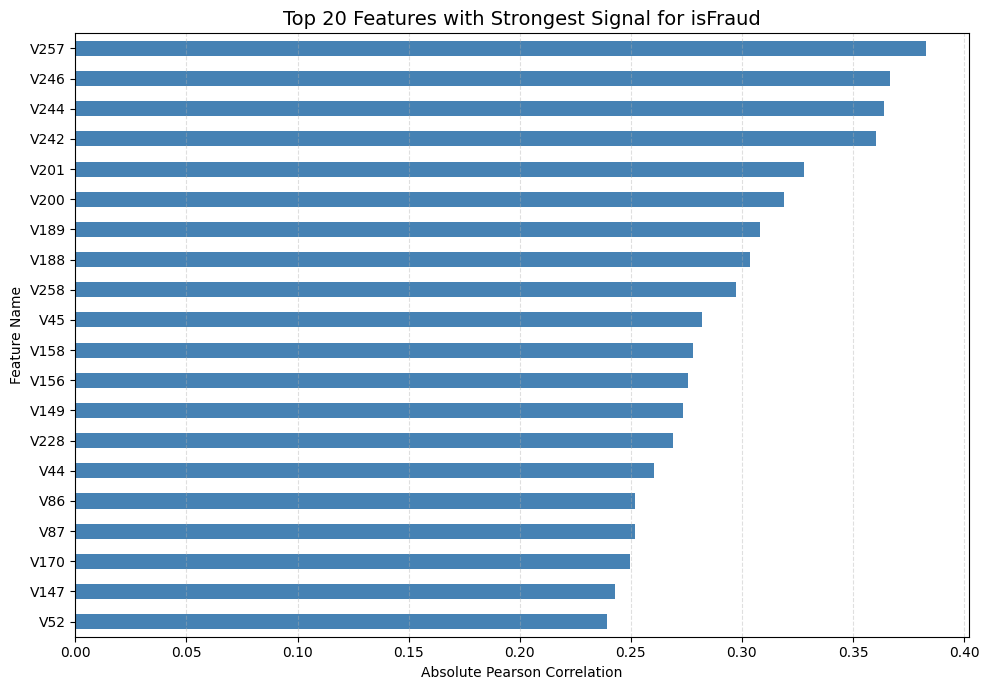

In [13]:
cols_to_check = df.select_dtypes(include=[np.number]).columns
cols_to_check = [c for c in cols_to_check if c not in ['TransactionID', 'TransactionDT']]

target_corr = df[cols_to_check].corr()['isFraud'].abs().sort_values(ascending=False)
top_20_target = target_corr.drop('isFraud', errors='ignore').head(20)

plt.figure(figsize=(10, 7))
top_20_target.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 20 Features with Strongest Signal for isFraud', fontsize=14)
plt.xlabel('Absolute Pearson Correlation')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**dropping unnecensary columns**

In [14]:
TARGET = 'isFraud'
X = df.drop(columns=[TARGET, 'TransactionID'])
y = df[TARGET]

**splitting**

In [15]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train_raw.shape}")
print(f"Val   : {X_val_raw.shape}")

del df, X
gc.collect()

Train : (472432, 432)
Val   : (118108, 432)


36999

**cleaning**

In [16]:
NAN_THRESH = 0.90

run = mlflow.start_run(run_name="DT_Cleaning")
try:
    miss_ratio   = X_train_raw.isnull().mean()
    cols_to_drop = miss_ratio[miss_ratio > NAN_THRESH].index.tolist()

    X_train_c = X_train_raw.drop(columns=cols_to_drop).copy()
    X_val_c   = X_val_raw.drop(columns=cols_to_drop).copy()

    print(f"Dropped {len(cols_to_drop)} cols | Remaining: {X_train_c.shape[1]}")

    cat_cols_c = X_train_c.select_dtypes(include='object').columns.tolist()
    num_cols_c = X_train_c.select_dtypes(
        include=['float32','float64','int32','int64']).columns.tolist()

    num_medians = X_train_c[num_cols_c].median()
    X_train_c[num_cols_c] = X_train_c[num_cols_c].fillna(num_medians)
    X_val_c[num_cols_c]   = X_val_c[num_cols_c].fillna(num_medians)

    X_train_c[cat_cols_c] = X_train_c[cat_cols_c].fillna('missing')
    X_val_c[cat_cols_c]   = X_val_c[cat_cols_c].fillna('missing')

    for col in X_train_c.select_dtypes('float64').columns:
        X_train_c[col] = X_train_c[col].astype('float32')
        X_val_c[col]   = X_val_c[col].astype('float32')
    for col in X_train_c.select_dtypes('int64').columns:
        X_train_c[col] = X_train_c[col].astype('int32')
        X_val_c[col]   = X_val_c[col].astype('int32')

    print(f"NaN remaining : {X_train_c.isnull().sum().sum()}")

    mlflow.log_param("nan_threshold",    NAN_THRESH)
    mlflow.log_param("cols_dropped",     len(cols_to_drop))
    mlflow.log_param("num_imputation",   "median")
    mlflow.log_param("cat_imputation",   "constant_missing")
    mlflow.log_param("scaling",          "none_not_needed")
    mlflow.log_metric("cols_remaining",  X_train_c.shape[1])

    print("Cleaning done.")

except Exception as e:
    print(f"Error: {e}")
    raise e
finally:
    mlflow.end_run()

Dropped 12 cols | Remaining: 420
NaN remaining : 0
Cleaning done.
🏃 View run DT_Cleaning at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/00e1c0a100134f98aa99ad75920d772b
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5


**feature engineering**

In [17]:
from sklearn.preprocessing import OrdinalEncoder

run = mlflow.start_run(run_name="DT_FeatureEngineering")
try:
    def add_features(df_):
        new_cols = {
            'amt_log':      np.log1p(df_['TransactionAmt']),
            'tx_hour':      (df_['TransactionDT'] // 3600) % 24,
            'tx_dayofweek': (df_['TransactionDT'] // (3600 * 24)) % 7,
            'tx_is_night':  ((df_['TransactionDT'] // 3600) % 24).apply(
                             lambda h: 1 if h < 6 or h >= 22 else 0).astype('int8'),
        }
        return pd.concat([df_, pd.DataFrame(new_cols, index=df_.index)], axis=1)

    card1_mean  = X_train_c.groupby('card1')['TransactionAmt'].mean()
    card1_count = X_train_c.groupby('card1')['TransactionAmt'].count()

    def add_aggs(df_):
        new_cols = {
            'card1_mean_amt': df_['card1'].map(card1_mean).fillna(0),
            'card1_tx_count': df_['card1'].map(card1_count).fillna(0),
        }
        return pd.concat([df_, pd.DataFrame(new_cols, index=df_.index)], axis=1)

    X_train_fe = add_features(X_train_c)
    X_train_fe = add_aggs(X_train_fe)
    X_val_fe   = add_features(X_val_c)
    X_val_fe   = add_aggs(X_val_fe)


    cat_cols_fe = X_train_fe.select_dtypes(include='object').columns.tolist()
    enc = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        dtype='float32'
    )
    X_train_fe[cat_cols_fe] = enc.fit_transform(X_train_fe[cat_cols_fe])
    X_val_fe[cat_cols_fe]   = enc.transform(X_val_fe[cat_cols_fe])

    print(f"Features after engineering : {X_train_fe.shape[1]}")

    mlflow.log_param("new_features",      ['amt_log','tx_hour','tx_dayofweek',
                                            'tx_is_night','card1_mean_amt',
                                            'card1_tx_count'])
    mlflow.log_param("cat_encoding",      "OrdinalEncoder")
    mlflow.log_metric("n_features_after_fe", X_train_fe.shape[1])

    print("Feature engineering done.")

except Exception as e:
    print(f"Error: {e}")
    raise e
finally:
    mlflow.end_run()

Features after engineering : 426
Feature engineering done.
🏃 View run DT_FeatureEngineering at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/61f761b2206d4073a43c340efb2358b8
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5


**feature selection**

Start : 426 features
After VarianceThreshold : 401 features
After DT Importance (top 60) : 60 features


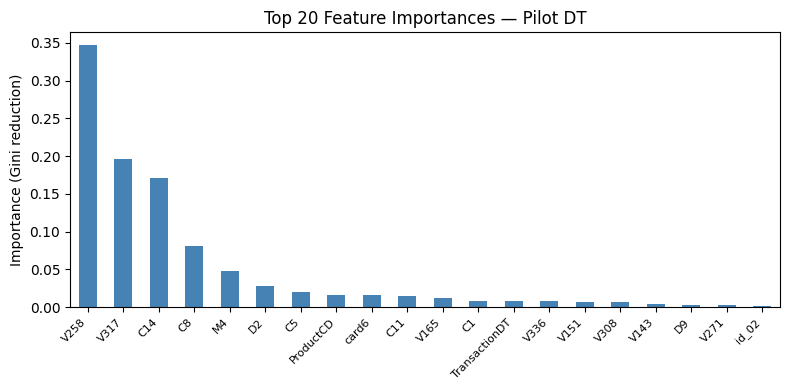

Feature selection done.
🏃 View run DT_FeatureSelection at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/2fc4671429fa4a5493158970eaf0a378
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5


In [18]:
from sklearn.tree import DecisionTreeClassifier

run = mlflow.start_run(run_name="DT_FeatureSelection")
try:
    X_tr = X_train_fe.copy()
    X_vl = X_val_fe.copy()

    print(f"Start : {X_tr.shape[1]} features")

    # Variance Threshold
    VT_THRESH = 0.01
    vt = VarianceThreshold(threshold=VT_THRESH)
    vt.fit(X_tr)
    X_tr = X_tr.loc[:, vt.get_support()]
    X_vl = X_vl.loc[:, vt.get_support()]
    print(f"After VarianceThreshold : {X_tr.shape[1]} features")

    # Pilot DT on sample
    SAMPLE_SIZE = 50_000
    idx = (pd.Series(y_train.values)
           .groupby(y_train.values)
           .apply(lambda x: x.sample(
               min(int(SAMPLE_SIZE * x.shape[0] / len(y_train)), len(x)),
               random_state=42))
           .reset_index(level=0, drop=True)
           .index)

    X_sample = X_tr.iloc[idx]
    y_sample = y_train.iloc[idx]

    pilot_dt = DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    )
    pilot_dt.fit(X_sample, y_sample)

    TOP_N = 60
    importances = pd.Series(
        pilot_dt.feature_importances_,
        index=X_tr.columns
    ).sort_values(ascending=False)

    selected_features = importances.head(TOP_N).index.tolist()
    X_tr = X_tr[selected_features]
    X_vl = X_vl[selected_features]
    print(f"After DT Importance (top {TOP_N}) : {X_tr.shape[1]} features")

    # top 20
    plt.figure(figsize=(8, 4))
    importances.head(20).plot(kind='bar', color='steelblue')
    plt.title('Top 20 Feature Importances — Pilot DT')
    plt.ylabel('Importance (Gini reduction)')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig('dt_feature_importance.png', dpi=100)
    plt.show()

    mlflow.log_param("vt_threshold",       VT_THRESH)
    mlflow.log_param("selection_method",   "PilotDT_GiniImportance")
    mlflow.log_param("pilot_max_depth",    5)
    mlflow.log_param("pilot_sample_size",  SAMPLE_SIZE)
    mlflow.log_param("top_n_features",     TOP_N)
    mlflow.log_metric("n_features_final",  len(selected_features))
    mlflow.log_artifact("dt_feature_importance.png")

    print("Feature selection done.")

except Exception as e:
    print(f"Error: {e}")
    raise e
finally:
    mlflow.end_run()

X_train_fs = X_tr.copy()
X_val_fs   = X_vl.copy()
SELECTED_FEATURES = selected_features

**model training**

In [19]:
def evaluate(model, X_tr, y_tr, X_vl, y_vl, label):
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    vl_auc = roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
    gap    = tr_auc - vl_auc
    print(f"  {label:50s}  Train={tr_auc:.4f}  Val={vl_auc:.4f}  Gap={gap:.4f}")
    return tr_auc, vl_auc, gap

**depths**

In [20]:
depth_configs = [
    ("DT_depth2",  dict(max_depth=2,    min_samples_leaf=1,
                                  class_weight='balanced', random_state=42)),
    ("DT_depth5",           dict(max_depth=5,    min_samples_leaf=1,
                                  class_weight='balanced', random_state=42)),
    ("DT_depth10",          dict(max_depth=10,   min_samples_leaf=1,
                                  class_weight='balanced', random_state=42)),
    ("DT_depth20",          dict(max_depth=20,   min_samples_leaf=1,
                                  class_weight='balanced', random_state=42)),
    ("DT_depthNone", dict(max_depth=None, min_samples_leaf=1,
                                  class_weight='balanced', random_state=42)),
]

depth_results = {}

for run_name, cfg in depth_configs:
    run = mlflow.start_run(run_name=run_name)
    try:
        model = DecisionTreeClassifier(**cfg)
        model.fit(X_train_fs, y_train)
        tr, vl, gap = evaluate(model, X_train_fs, y_train,
                                X_val_fs, y_val, run_name)
        mlflow.log_params(cfg)
        mlflow.log_metric("train_auc", tr)
        mlflow.log_metric("val_auc",   vl)
        mlflow.log_metric("gap",       gap)
        mlflow.set_tag("phase", "depth_sweep")
        depth_results[run_name] = {
            "model": model, "tr": tr,
            "vl": vl, "gap": gap, "cfg": cfg
        }
    finally:
        mlflow.end_run()

best_depth_run = max(depth_results, key=lambda k: depth_results[k]["vl"])
best_depth     = depth_results[best_depth_run]["cfg"]["max_depth"]
print(f"\nBest depth : {best_depth}  "
      f"Val AUC={depth_results[best_depth_run]['vl']:.4f}")

  DT_depth2                                           Train=0.7158  Val=0.7188  Gap=-0.0030
🏃 View run DT_depth2 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/85cb35897f54495abd5312d0d90c1af5
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_depth5                                           Train=0.8192  Val=0.8188  Gap=0.0004
🏃 View run DT_depth5 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/d0fe5ff59bef42b9a8e124f6556baa37
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_depth10                                          Train=0.8868  Val=0.8662  Gap=0.0206
🏃 View run DT_depth10 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/3b8474330dec434a8f5f9d7563ff6655
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_depth20                                          Train=0.9667  Val=0.7821  Gap=0.1846
🏃 View run DT_depth20 at:

**leaves**

In [21]:
leaf_configs = [
    ("DT_leaf1",    dict(max_depth=best_depth, min_samples_leaf=1,
                          class_weight='balanced', random_state=42)),
    ("DT_leaf10",   dict(max_depth=best_depth, min_samples_leaf=10,
                          class_weight='balanced', random_state=42)),
    ("DT_leaf50",   dict(max_depth=best_depth, min_samples_leaf=50,
                          class_weight='balanced', random_state=42)),
    ("DT_leaf100",  dict(max_depth=best_depth, min_samples_leaf=100,
                          class_weight='balanced', random_state=42)),
    ("DT_leaf500",  dict(max_depth=best_depth, min_samples_leaf=500,
                          class_weight='balanced', random_state=42)),
    ("DT_leaf2000", dict(max_depth=best_depth, min_samples_leaf=2000,
                            class_weight='balanced', random_state=42)),
]

leaf_results = {}

for run_name, cfg in leaf_configs:
    run = mlflow.start_run(run_name=run_name)
    try:
        model = DecisionTreeClassifier(**cfg)
        model.fit(X_train_fs, y_train)
        tr, vl, gap = evaluate(model, X_train_fs, y_train,
                                X_val_fs, y_val, run_name)
        mlflow.log_params(cfg)
        mlflow.log_metric("train_auc", tr)
        mlflow.log_metric("val_auc",   vl)
        mlflow.log_metric("gap",       gap)
        mlflow.set_tag("phase", "leaf_sweep")
        leaf_results[run_name] = {
            "model": model, "tr": tr,
            "vl": vl, "gap": gap, "cfg": cfg
        }
        
    finally:
        mlflow.end_run()


best_leaf_run = max(leaf_results, key=lambda k: leaf_results[k]["vl"])
best_leaf     = leaf_results[best_leaf_run]["cfg"]["min_samples_leaf"]
print(f"\nBest min_samples_leaf : {best_leaf}  "
      f"Val AUC={leaf_results[best_leaf_run]['vl']:.4f}")

  DT_leaf1                                            Train=0.8868  Val=0.8662  Gap=0.0206
🏃 View run DT_leaf1 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/d5c6ff0b9593480fae858cbf17d6bf9a
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_leaf10                                           Train=0.8869  Val=0.8663  Gap=0.0207
🏃 View run DT_leaf10 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/fab80feea9b244ab97ac6c7fb7b0e435
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_leaf50                                           Train=0.8851  Val=0.8702  Gap=0.0149
🏃 View run DT_leaf50 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/ad171a57e6cc4c89a873aedf4cbcef3c
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_leaf100                                          Train=0.8828  Val=0.8713  Gap=0.0115
🏃 View run DT_leaf100 at: ht

**criterions**

In [22]:
criterion_configs = [
    ("DT_Gini",    dict(max_depth=best_depth, min_samples_leaf=best_leaf,
                         criterion='gini',
                         class_weight='balanced', random_state=42)),
    ("DT_Entropy", dict(max_depth=best_depth, min_samples_leaf=best_leaf,
                         criterion='entropy',
                         class_weight='balanced', random_state=42)),
]

criterion_results = {}

for run_name, cfg in criterion_configs:
    run = mlflow.start_run(run_name=run_name)
    try:
        model = DecisionTreeClassifier(**cfg)
        model.fit(X_train_fs, y_train)
        tr, vl, gap = evaluate(model, X_train_fs, y_train,
                                X_val_fs, y_val, run_name)
        mlflow.log_params(cfg)
        mlflow.log_metric("train_auc", tr)
        mlflow.log_metric("val_auc",   vl)
        mlflow.log_metric("gap",       gap)
        mlflow.set_tag("phase", "criterion_comparison")
        criterion_results[run_name] = {
            "model": model, "tr": tr,
            "vl": vl, "gap": gap, "cfg": cfg
        }
    finally:
        mlflow.end_run()


best_criterion_run = max(criterion_results, key=lambda k: criterion_results[k]["vl"])
best_criterion     = criterion_results[best_criterion_run]["cfg"]["criterion"]
print(f"\nBest criterion : {best_criterion}  "
      f"Val AUC={criterion_results[best_criterion_run]['vl']:.4f}")

  DT_Gini                                             Train=0.8828  Val=0.8713  Gap=0.0115
🏃 View run DT_Gini at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/a17be983bb8842b2946dd67203d16a4f
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
  DT_Entropy                                          Train=0.8818  Val=0.8692  Gap=0.0126
🏃 View run DT_Entropy at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/47e32d2e97134dc0a0aaee75a1a4309c
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5

Best criterion : gini  Val AUC=0.8713


**experiments' results**

In [23]:
all_rows = []

for name, r in depth_results.items():
    all_rows.append({
        "Phase":      "1_depth",
        "Run":        name,
        "max_depth":  str(r["cfg"]["max_depth"]),
        "min_leaf":   r["cfg"]["min_samples_leaf"],
        "criterion":  r["cfg"].get("criterion", "gini"),
        "Train AUC":  round(r["tr"],  4),
        "Val AUC":    round(r["vl"],  4),
        "Gap":        round(r["gap"], 4),
    })

for name, r in leaf_results.items():
    all_rows.append({
        "Phase":      "2_leaf",
        "Run":        name,
        "max_depth":  str(r["cfg"]["max_depth"]),
        "min_leaf":   r["cfg"]["min_samples_leaf"],
        "criterion":  r["cfg"].get("criterion", "gini"),
        "Train AUC":  round(r["tr"],  4),
        "Val AUC":    round(r["vl"],  4),
        "Gap":        round(r["gap"], 4),
    })

for name, r in criterion_results.items():
    all_rows.append({
        "Phase":      "3_criterion",
        "Run":        name,
        "max_depth":  str(r["cfg"]["max_depth"]),
        "min_leaf":   r["cfg"]["min_samples_leaf"],
        "criterion":  r["cfg"].get("criterion", "gini"),
        "Train AUC":  round(r["tr"],  4),
        "Val AUC":    round(r["vl"],  4),
        "Gap":        round(r["gap"], 4),
    })

summary = pd.DataFrame(all_rows).sort_values(
    ["Phase", "Val AUC"], ascending=[True, False])
print(summary.to_string(index=False))

      Phase          Run max_depth  min_leaf criterion  Train AUC  Val AUC     Gap
    1_depth   DT_depth10        10         1      gini     0.8868   0.8662  0.0206
    1_depth    DT_depth5         5         1      gini     0.8192   0.8188  0.0004
    1_depth   DT_depth20        20         1      gini     0.9667   0.7821  0.1846
    1_depth DT_depthNone      None         1      gini     1.0000   0.7274  0.2726
    1_depth    DT_depth2         2         1      gini     0.7158   0.7188 -0.0030
     2_leaf   DT_leaf100        10       100      gini     0.8828   0.8713  0.0115
     2_leaf    DT_leaf50        10        50      gini     0.8851   0.8702  0.0149
     2_leaf   DT_leaf500        10       500      gini     0.8743   0.8682  0.0061
     2_leaf    DT_leaf10        10        10      gini     0.8869   0.8663  0.0207
     2_leaf     DT_leaf1        10         1      gini     0.8868   0.8662  0.0206
     2_leaf  DT_leaf2000        10      2000      gini     0.8608   0.8577  0.0031
3_cr

**best on cv**

In [24]:
best_cfg_final = {
    "max_depth":        best_depth,
    "min_samples_leaf": best_leaf,
    "criterion":        best_criterion,
    "class_weight":     "balanced",
    "random_state":     42
}

run = mlflow.start_run(run_name="DT_CrossValidation")
try:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        DecisionTreeClassifier(**best_cfg_final),
        X_train_fs, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )

    print(f"Fold scores : {cv_scores.round(4)}")
    print(f"Mean AUC    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    mlflow.log_params(best_cfg_final)
    mlflow.log_param("cv_folds",     5)
    mlflow.log_metric("cv_mean_auc", cv_scores.mean())
    mlflow.log_metric("cv_std_auc",  cv_scores.std())
    for i, s in enumerate(cv_scores):
        mlflow.log_metric(f"fold_{i+1}_auc", float(s))

finally:
    mlflow.end_run()

Fold scores : [0.8636 0.8637 0.8674 0.8638 0.8707]
Mean AUC    : 0.8659 ± 0.0028
🏃 View run DT_CrossValidation at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/b03a899920084fbca1c02a09828a314c
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5


**pipeline**

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin

class DropHighNaN(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold

    def fit(self, X, y=None):
        df_ = pd.DataFrame(X)
        miss = df_.isnull().mean()
        self.drop_cols_ = miss[miss > self.threshold].index.tolist()
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.drop(columns=[c for c in self.drop_cols_ if c in df_.columns])


class DTPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df_ = pd.DataFrame(X)
        self.cat_cols_ = df_.select_dtypes(include='object').columns.tolist()
        self.num_cols_ = df_.select_dtypes(
            include=['float32','float64','int32','int64']).columns.tolist()

        self.medians_     = df_[self.num_cols_].median()
        self.card1_mean_  = df_.groupby('card1')['TransactionAmt'].mean().to_dict()
        self.card1_count_ = df_.groupby('card1')['TransactionAmt'].count().to_dict()

        df_cat = df_[self.cat_cols_].fillna('missing')
        self.enc_ = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
            dtype='float32'
        )
        self.enc_.fit(df_cat)
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X).copy()

        for col in self.num_cols_:
            if col in df_.columns:
                df_[col] = df_[col].fillna(self.medians_[col])

        for col in self.cat_cols_:
            if col not in df_.columns:
                df_[col] = 'missing'
            else:
                df_[col] = df_[col].fillna('missing')

        df_[self.cat_cols_] = self.enc_.transform(df_[self.cat_cols_])

        new_cols = {
            'amt_log':        np.log1p(df_['TransactionAmt']),
            'tx_hour':        (df_['TransactionDT'] // 3600) % 24,
            'tx_dayofweek':   (df_['TransactionDT'] // (3600 * 24)) % 7,
            'tx_is_night':    ((df_['TransactionDT'] // 3600) % 24).apply(
                               lambda h: 1 if h < 6 or h >= 22 else 0).astype('int8'),
            'card1_mean_amt': df_['card1'].map(self.card1_mean_).fillna(0),
            'card1_tx_count': df_['card1'].map(self.card1_count_).fillna(0),
        }
        df_ = pd.concat([df_, pd.DataFrame(new_cols, index=df_.index)], axis=1)

        return df_.copy()


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        keep = [c for c in self.cols if c in df_.columns]
        return df_[keep].values

In [26]:
pipeline_dt = Pipeline([
    ('drop_nan',     DropHighNaN(threshold=0.90)),
    ('preprocessor', DTPreprocessor()),
    ('selector',     ColumnSelector(cols=SELECTED_FEATURES)),
    ('model',        DecisionTreeClassifier(**best_cfg_final))
])

pipeline_dt.fit(
    X_train_raw.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

val_proba    = pipeline_dt.predict_proba(X_val_raw.reset_index(drop=True))[:, 1]
pipeline_auc = roc_auc_score(y_val, val_proba)
print(f"Pipeline Val AUC : {pipeline_auc:.4f}")

Pipeline Val AUC : 0.8713


**registration**

In [27]:
run = mlflow.start_run(run_name="DT_Pipeline_Registration")

try:
    mlflow.log_params(best_cfg_final)
    mlflow.log_param("pipeline_steps",   [s[0] for s in pipeline_dt.steps])
    mlflow.log_metric("pipeline_val_auc", pipeline_auc)

    mlflow.sklearn.log_model(
        sk_model=pipeline_dt,
        artifact_path="dt_finalpipeline",
        registered_model_name="DT_FinalPipeline",
        input_example=X_train_raw.head(2)
    )

    print("Registered as : DT_FinalPipeline")
    print(f"Tracking URI : {mlflow.get_tracking_uri()}")

finally:
    mlflow.end_run()

2026/05/05 13:31:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 13:31:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can 

Registered as : DT_FinalPipeline
Tracking URI : https://dagshub.com/akeke23/ml_ass2.mlflow
🏃 View run DT_Pipeline_Registration at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5/runs/a8321bff628e41a88f6fb8645263cbb8
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/5
